# Reward terms: rewards and shaping

A GRPO reward term is two things:

- a **reward** -- `f(idr) -> float`, reporting one raw value in its own units (bits, residues,
  angstroms, a fraction);
- **shaping** -- what counts as a good value for it.

Keeping them apart is why one reward can be maximized, aimed at a target, or held above a floor
without being rewritten, and why the same one can appear twice in an objective under different
labels. The total is

$$\text{total} = \sum_i w_i \cdot \text{shaping}_i(\text{reward}_i(\text{idr}))$$

Three names run through the code, since the bare word is ambiguous once a term is assembled: the
**raw reward** is what the function returns, the **shaped reward** is that value after shaping,
and the **total reward** is the weighted sum GRPO optimizes.

Nothing here needs a GPU, weights, or a network.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from idiom.train.grpo.reward import (
    REWARD_REGISTRY, Batch, build_reward, build_shaping, get_reward, import_module_spec,
)

sorted(REWARD_REGISTRY)

['entropy', 'length']

Two rewards are built in. `entropy` returns composition entropy in bits and `length`
returns residues -- raw numbers, with no notion of a target.

In [2]:
IDRS = [
    "FFWYFFWYFFWYFFWY",                 # aromatic, low entropy
    "GSGSGSGSGSGSGSGS",                 # two residues, very low entropy
    "MEDSKVDNRPQACDEFGHIKLMNPQRSTVWY",  # varied
]

for name in ("entropy", "length"):
    raw = get_reward(name)(IDRS, Batch())
    print(f"{name:>8}: {[round(v, 2) for v in raw]}")

 entropy: [1.5, 1.0, 4.22]
  length: [16.0, 16.0, 31.0]


## Your own reward

Register `f(idr) -> float` in any module and name it in the config. `rewards/custom_rewards.py` is
the copy-me file; `import_module_spec` is the same mechanism the config's `module:` key uses.

In [3]:
import_module_spec("rewards/custom_rewards.py")

aromatic = get_reward("aromatic_fraction")
print("aromatic_fraction:", [round(v, 3) for v in aromatic(IDRS, Batch())])

aromatic_fraction: [1.0, 0.0, 0.097]


## Shaping

The reward stops at the raw value. Shaping carries the intent, and it is chosen in the config,
not in the code:

| type | parameters | reads as |
|---|---|---|
| omitted | -- | use the raw reward; for a fraction, push it up |
| `quadratic` | `target`, `width` | hit this value; unbounded below |
| `gaussian` | `target`, `width` | hit this value; bounded, but flat far away |
| `zscore` | -- | standardize within each rollout group |

`width` is a fraction of the target, so `width: 0.2` means a 20% tolerance.

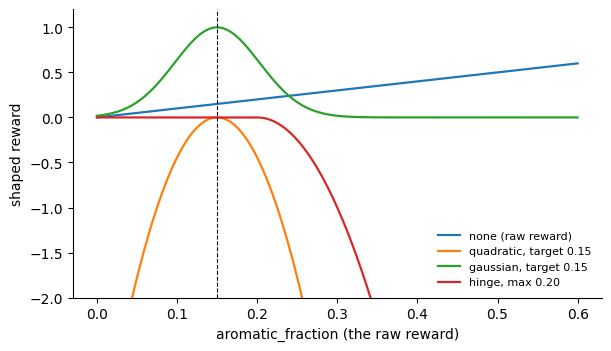

In [4]:
grid = np.linspace(0.0, 0.6, 400)

shaping_rules = {
    "none (raw reward)": build_shaping(None),
    "quadratic, target 0.15": build_shaping({"type": "quadratic", "target": 0.15, "width": 0.5}),
    "gaussian, target 0.15": build_shaping({"type": "gaussian", "target": 0.15, "width": 0.5}),
}

fig, ax = plt.subplots(figsize=(6, 3.4), constrained_layout=True)
for label, shaping in shaping_rules.items():
    ax.plot(grid, shaping(list(grid), Batch()), lw=1.6, label=label)
ax.axvline(0.15, ls="--", lw=0.8, color="#110d1b")
ax.set_ylim(-2.0, 1.2)
ax.set_xlabel("aromatic_fraction (the raw reward)")
ax.set_ylabel("shaped reward")
ax.legend(frameon=False, fontsize=8)
ax.spines[["top", "right"]].set_visible(False)
plt.show()

Read off the trade-off: `quadratic` keeps pushing back from any distance but can swamp
every other term when it starts far away; `gaussian` cannot dominate but flattens, so out there it
stops telling good from worse.

## A whole objective

`build_reward` takes the config's `reward` block and returns the function GRPO calls each step. It
validates as it builds, so a bad term fails here rather than after the model loads.

In [5]:
from omegaconf import OmegaConf

cfg = OmegaConf.create({"module": None, "terms": [
    {"reward": "entropy", "weight": 1.0,
     "shaping": {"type": "quadratic", "target": 3.65, "width": 0.2}},
    {"reward": "length", "weight": 1.0,
     "shaping": {"type": "quadratic", "target": 100, "width": 1.0}},
    {"reward": "aromatic_fraction", "module": "rewards/custom_rewards.py", "weight": 3.0},
]})

totals, breakdown = build_reward(cfg)(IDRS, group_size=1)

keys = ["entropy", "length", "aromatic_fraction"]
print(f"{'idr':<20}" + "".join(f"{k:>22}" for k in keys) + f"{'total':>10}")
for idr, row, total in zip(IDRS, breakdown, totals):
    cells = "".join(f"{row[k + '_raw']:>10.2f} ->{row[k]:>9.2f}" for k in keys)
    print(f"{idr[:18]:<20}{cells}{total:>10.2f}")

idr                                entropy                length     aromatic_fraction     total
FFWYFFWYFFWYFFWY          1.50 ->    -8.67     16.00 ->    -0.71      1.00 ->     3.00     -6.38
GSGSGSGSGSGSGSGS          1.00 ->   -13.18     16.00 ->    -0.71      0.00 ->     0.00    -13.88
MEDSKVDNRPQACDEFGH        4.22 ->    -0.61     31.00 ->    -0.48      0.10 ->     0.29     -0.80


Each term is logged twice, and that is what you watch during training: `<label>_raw` is
the raw reward in its own units (98 residues, 3.6 bits) and `<label>` is what it contributed to the
total. A term with `weight: 0` is scored and logged but does not steer training; a term with
`enabled: false` is skipped entirely.

In [6]:
bad = OmegaConf.create({"terms": [{"reward": "length", "shaping": {"type": "quadratic"}}]})
try:
    build_reward(bad)
except ValueError as e:
    print("rejected at build time:", e)

rejected at build time: bad parameters for shaping 'quadratic': _quadratic() missing 1 required keyword-only argument: 'target'


## Running it

The shipped `configs/grpo.yaml` carries these as a menu of terms, switched off. Enable one from the
command line:

```bash
idiom_grpo init_from=jxliu2/idiom-300M reward.terms.3.enabled=true   # aromatic_fraction
```

For a real run use the Slurm templates: `examples/slurm/grpo.bash` for the built-in reward, or
`examples/slurm/grpo_external.bash` for a reward model that runs in its own environment. The
top-level README's reward section covers writing an external scorer.